# Research Workflow

This notebook demonstrates the research [workflow](https://langchain-ai.github.io/langgraph/tutorials/workflows/) that creates comprehensive reports through a series of focused steps. The system:

1. Uses a **graph workflow** with specialized nodes for each report creation stage
2. Enables user **feedback and approval** at critical planning points 
3. Produces a well-structured report with introduction, researched body sections, and conclusion

## From repo 

In [39]:
#To start a fresh venv, delete the old one in file explore
#Then use this command: python -m venv .venv
#Then activate it using python interpreter (ctr + shift + P)
#Select the venv path, then open new vs code terminal and you should see the (.venv)

In [40]:
%cd ..
%load_ext autoreload
%autoreload 2

c:\Users\vedan\GitHub
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## From package 

In [41]:
! pip install -U -q open-deep-research

# Compile the Graph-Based Research Workflow

The next step is to compile the LangGraph workflow that orchestrates the report creation process. This defines the sequence of operations and decision points in the research pipeline.

In [42]:
import uuid
import os, getpass
import sys
sys.path.append('/path/to/open_deep_research/src')  # Add the src directory to the path

from IPython.display import Image, display, Markdown
from langgraph.types import Command
from langgraph.checkpoint.memory import MemorySaver
from legacy.graph import builder  # Import from legacy.graph instead

In [43]:
# Create a memory-based checkpointer and compile the graph
# This enables state persistence and tracking throughout the workflow execution

memory = MemorySaver()
graph = builder.compile(checkpointer=memory)

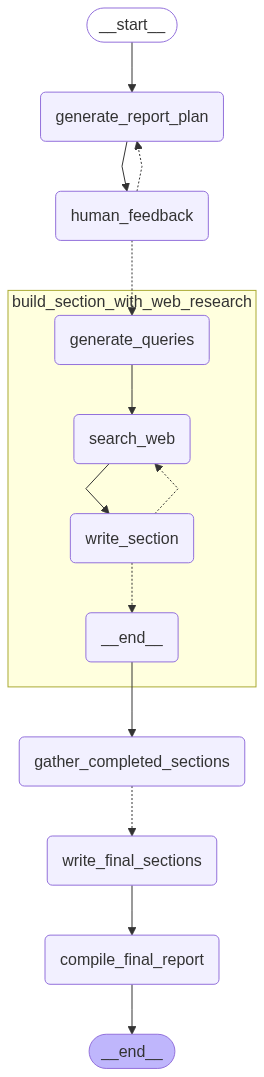

In [44]:
# Visualize the graph structure
# This shows the nodes and edges in the research workflow

display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [45]:
# Helper function to set environment variables for API keys
# This ensures all necessary credentials are available for various services

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")
        

# Set the API keys used for any model or search tool selections below, such as:
#_set_env("OPENAI_API_KEY")
# _set_env("ANTHROPIC_API_KEY")
#_set_env("TAVILY_API_KEY")
# _set_env("GROQ_API_KEY")
# _set_env("PERPLEXITY_API_KEY")

In [46]:
# Define report structure template and configure the research workflow
# This sets parameters for models, search tools, and report organization

REPORT_STRUCTURE = """Use this structure to create a introduction on the user-provided topic:

You are a research paper summarizer assisting professors when they want to learn
more about a specific field. Your task is to generate a compelling
introduction about the topic that the professor inputs. You are also a top level researcher
in this field. You are extremly specific and detial orientented and that is shown in the
introductions that you write.The introduction should effectively summarize the current state
of research, identify a research gap, and highlight the novelty and contribution of the paper.
Avoid including irrelevant details or overly technical explanations that are not
necessary for an introduction. Use intext MLA citations. 

The introduction should be structured as follows:

1.  **Background:** Begin with a broad overview of the topic the researcher enters and the significance of the research topic.
Explain the existing challenges and the importance of addressing the problem.

2.  **Literature Review and Research Gap:** Summarize relevant previous work in the field. Discuss the limitations of existing approaches
and clearly articulate the research gap that this paper aims to address.

3.  **Contribution and Novelty:** Present the proposed solution and explain how it is innovative and different from previous work.
Clearly state the key contributions of this research and its potential impact.

The introduction should be written in a formal and academic tone, using precise language and technical jargon where appropriate.
It should be concise yet comprehensive, effectively capturing the essence of the paper. For now do not add the third section
(Contribution and Novelty) and inplace of that just put a placeholder. 

Make sure :
--> To double check each fact before using mentioning it in the report. 
--> That you are not just combining facts, but rather explaining a topic with facts and turning the report into a cohesive story. 
--> To synthesize information from multiple sources to provide a nuanced view  
--> To cross-verify key numbers to ensure the most accurate figure is used, especially when multiple sources offer slightly different values.

Here is an example of a well-written introduction:
***
On 4 July 2019, seismic activity initiated near Ridgecrest, California, and escalated over the next 2 hr
culminating with the occurrence of the first principle mainshock MW 6.4 at 17:33 UTC. It was followed by
an intense aftershock sequence leading up to the occurrence of the second mainshock, MW 7.1 at 03:19
UTC on 6 July 2019. The MW 6.4 and 7.1 mainshocks occurred closely in space (10‐km separation) and
activated a complex fault network composed of conjugate strike‐slip faults including the NW‐trending main
fault with about 65‐km‐long surface rupture and NE‐treading fault with ~15‐km‐long surface rupture
(Barnhart et al., 2019; Goldberg et al., 2019; Kendrick et al., 2019; Liu et al., 2019; Ross et al., 2019;
Figure 1). A high‐precision near real‐time catalog enables us to rapidly characterize the earthquake sequence
(Stewart, 1977), such as tracking seismicity evolution (Peng & Zhao, 2009; Ross et al., 2017; Zhang & Wen,
2015a) and identification of causative faults (Kao & Shan, 2007; Yang et al., 2009). The challenge is to build
a high‐precision earthquake catalog in near real‐time when the event rate becomes extreme.
Earthquake catalog building strongly depends on earthquake detection and location techniques. Two main
classes of methods are widely used in earthquake detection and location: pick‐based methods and
waveform‐based methods (Grigoli et al., 2018; Pesicek et al., 2014; Stewart, 1977; Zhang et al., 2019).
Independent of seismic phase picking, waveform‐based methods detect, associate, and locate earthquakes
simultaneously in a single step based on the delay‐and‐sum concept (Kao & Shan, 2004; Peng & Zhao,
2009; Shelly et al., 2007; Zhang & Wen, 2015b). They are sensitive to small earthquakes by maximizing
seismic energy or coherence but suffer from high computational costs due to their exhaustive searching in
space and time. Consequently, pick‐based methods are still the preferred solution for routine earthquake
monitoring due to their high computational efficiency (Grigoli et al., 2018). Seismic picks are conventionally
obtained from handpicking or automatic picking algorithms such as the short‐term average/long‐term
average picker (Allen, 1978; Withers et al., 1998). Recently, machine‐learning techniques have been
widely adopted in seismic phase picking, showing promise in both picking efficiency and picking accuracy
(e.g., Ross et al., 2018; Wang et al., 2019; Zhu et al., 2019; Zhu & Beroza, 2019). A high‐precision earthquake
catalog provides a window into the details of seismic fault structures. Various
techniques have been widely used to investigate fault structures after earthquakes occurred but hampered by
different aspects, such as: Focal mechanism inversion methods are only eligible to reveal the major fault
plane (e.g., Gephart & Forsyth, 1984); geodetic observations have little depth resolution (e.g., Ward &
Valensise, 1989); and on‐site surveys are not able to investigate buried faults (e.g., Xu et al., 2009).
Earthquakes may be accommodated on known or newly activated faults (Ross et al., 2019; Waldhauser,2009; Waldhauser & Ellsworth, 2002).
Thus, accurate earthquake locations play an important role in deli-neation of detailed seismic fault structures.
In this study, we first build sequential earthquake catalogs for the 2019 Ridgecrest earthquake sequence
from continuous waveform data using a machine‐learning picker, a newly developed earthquake association
and location algorithm, and two other high‐precision location programs. Then we compare our catalogs with
other available catalogs. Our results clearly reveal the seismicity migration in space and time and character-
ize seismic fault structures activated during the earthquake sequence.
***"""

# # Configuration option 1: Claude 3.7 Sonnet for planning with perplexity search
# thread = {"configurable": {"thread_id": str(uuid.uuid4()),
#                            "search_api": "perplexity",
#                            "planner_provider": "anthropic",
#                            "planner_model": "claude-3-7-sonnet-latest",
#                            # "planner_model_kwargs": {"temperature":0.8}, # if set custom parameters
#                            "writer_provider": "anthropic",
#                            "writer_model": "claude-3-5-sonnet-latest",
#                            # "writer_model_kwargs": {"temperature":0.8}, # if set custom parameters
#                            "max_search_depth": 2,
#                            "report_structure": REPORT_STRUCTURE,
#                            }}

# # Configuration option 2: DeepSeek-R1-Distill-Llama-70B for planning and llama-3.3-70b-versatile for writing
# thread = {"configurable": {"thread_id": str(uuid.uuid4()),
#                            "search_api": "tavily",
#                            "planner_provider": "groq",
#                            "planner_model": "deepseek-r1-distill-llama-70b",
#                            "writer_provider": "groq",
#                            "writer_model": "llama-3.3-70b-versatile",
#                            "report_structure": REPORT_STRUCTURE,
#                            "max_search_depth": 1,}
#                            }

# Configuration option 3: Use OpenAI o3 for both planning and writing (selected option)
thread = {"configurable": {"thread_id": str(uuid.uuid4()),
                           "search_api": "tavily",
                           "planner_provider": "openai",
                           "planner_model": "gpt-4o-mini",
                           "writer_provider": "openai",
                           "writer_model": "gpt-4o-mini",
                           "max_search_depth": 2,
                           "report_structure": REPORT_STRUCTURE,
                           }} 

# Define research topic about Model Context Protocol
topic = "Explore mars' shallow and deep interiors using seismic data and write me a proper research paper introduction about this topic."
# Run the graph workflow until first interruption (waiting for user feedback)
async for event in graph.astream({"topic":topic,}, thread, stream_mode="updates"):
    if '__interrupt__' in event:
        interrupt_value = event['__interrupt__'][0].value
        display(Markdown(interrupt_value))

Please provide feedback on the following report plan. 
                        

Section: Introduction
Description: Provide an overview of the significance of exploring Mars' shallow and deep interiors using seismic data and outline the challenges faced in this research area.
Research needed: No


Section: Overview of Mars' Interior Structure
Description: Discuss the different layers of Mars' interior, including the crust, mantle, and core, based on existing seismic data and models. Explain the geological processes that contribute to these structures.
Research needed: Yes


Section: The InSight Mission and Its Seismic Data
Description: Detail the InSight mission specifically, including its objectives, instrumentation, and the collection of seismic data from the Martian surface. Highlight key findings from the seismic data analysis.
Research needed: Yes


Section: Comparison of Shallow and Deep Interior Insights
Description: Analyze how seismic data has enhanced the understanding of both the shallow and deep interior structures of Mars, emphasizing differences in the composition and behavior of seismic waves in these regions.
Research needed: Yes


Section: Challenges and Limitations in Mars Seismology
Description: Examine the specific challenges faced in studying Mars' interior, including limitations of current seismic analysis techniques and data interpretation. Discuss the impact of environmental factors unique to Mars.
Research needed: Yes


Section: Future Directions in Mars Interior Research
Description: Explore potential future research paths and technological advancements that may improve understanding of Mars' interior, particularly in areas not yet mapped or understood.
Research needed: Yes


Section: Conclusion
Description: Summarize the main findings and implications for future exploration and understanding of Mars' internal structure as driven by seismic data analysis.
Research needed: No


                        
Does the report plan meet your needs?
Pass 'true' to approve the report plan.
Or, provide feedback to regenerate the report plan:

# User Feedback Phase

* This allows for providing directed feedback on the initial report plan
* The user can review the proposed report structure and provide specific guidance
* The system will incorporate this feedback into the final report plan

In [47]:
# Submit feedback on the report plan
# The system will continue execution with the updated requirements

# Provide specific feedback to focus and refine the report structure
async for event in graph.astream(Command(resume=""), thread, stream_mode="updates"):
    if '__interrupt__' in event:
        interrupt_value = event['__interrupt__'][0].value
        display(Markdown(interrupt_value))

Please provide feedback on the following report plan. 
                        

Section: Introduction
Description: An overview of the significance of exploring Mars' interiors through seismic data, detailing the InSight mission's objectives.
Research needed: No


Section: Overview of the InSight Mission
Description: A detailed look at the InSight mission's objectives, instruments, and achievements in studying Mars' interior.
Research needed: Yes


Section: Seismic Data Collection and Analysis
Description: An examination of the seismic data gathered by InSight, including analysis techniques used to interpret the data regarding Mars' crust, mantle, and core.
Research needed: Yes


Section: Insights into Mars' Shallow Interior
Description: Discussion of findings related to the shallow layers of Mars, including details on the crust's composition and structure based on seismic data.
Research needed: Yes


Section: Insights into Mars' Deep Interior
Description: Analysis of the deep interior of Mars, including specifics about the mantle and core, derived from the seismic waves and data captured by InSight.
Research needed: Yes


Section: Comparative Analysis with Terrestrial Seismology
Description: A comparison of the techniques and findings of Martian seismology with those of terrestrial seismology, discussing similarities and differences in geological processes.
Research needed: Yes


Section: Conclusion
Description: A summary of the key findings from the report and their implications for understanding Mars and the broader context of planetary science.
Research needed: No


                        
Does the report plan meet your needs?
Pass 'true' to approve the report plan.
Or, provide feedback to regenerate the report plan:

# Final Approval Phase
* After incorporating feedback, approve the plan to start content generation

In [48]:
# Approve the final plan and execute the report generation
# This triggers the research and writing phases for all sections

# The system will now:
# 1. Research each section topic
# 2. Generate content with citations
# 3. Create introduction and conclusion
# 4. Compile the final report

async for event in graph.astream(Command(resume=True), thread, stream_mode="updates"):
    print(event)
    print("\n")

{'human_feedback': None}


{'build_section_with_web_research': {'completed_sections': [Section(name='Comparative Analysis with Terrestrial Seismology', description='A comparison of the techniques and findings of Martian seismology with those of terrestrial seismology, discussing similarities and differences in geological processes.', research=True, content="## Comparative Analysis with Terrestrial Seismology\n\nMartian seismology has become a vital field of study following the deployment of seismic instruments by the InSight mission, allowing comparisons with terrestrial seismology. Both Mars and Earth experience seismic events, known as marsquakes and earthquakes, respectively. However, the geological environments and behaviors of these seismic activities differ significantly. \n\nResearch indicates that the major types of seismic events on Mars can be categorized similarly to those on Earth, including shallow quakes, meteorite impacts, and possibly volcanic activity, as observed in r

In [49]:
# Display the final generated report
# Retrieve the completed report from the graph's state and format it for display

final_state = graph.get_state(thread)
report = final_state.values.get('final_report')
Markdown(report)

# Exploring Mars' Shallow and Deep Interiors Using Seismic Data

Understanding the internal structure of Mars is crucial for revealing the planet's geological history and evolutionary processes. The InSight mission, which stands for Interior Exploration using Seismic Investigations, Geodesy and Heat Transport, aims to advance our knowledge of Mars by utilizing seismic data to study its shallow and deep interiors. With state-of-the-art instruments, InSight has recorded over 1,300 marsquakes, highlighting an active interior and providing insights into the crust's composition, the state of the mantle, and the characteristics of the core. 

The subsequent sections delve into the findings from InSight, covering aspects such as the significant thickness and layered structure of the Martian crust, the dynamics of the deeper mantle and core, and the comparative analysis with terrestrial seismology. These insights pave the way for understanding Mars' past volcanic activity, its potential for habitability, and the overall geological complexity of the planet.

## Overview of the InSight Mission

The InSight mission, which stands for Interior Exploration using Seismic Investigations, Geodesy and Heat Transport, has significantly contributed to our understanding of Mars. Launched on May 5, 2018, InSight landed at Elysium Planitia on November 26, 2018. Its primary objective was to unravel the inner workings of Mars by studying its seismic activity and heat flow, providing insights into the planet's formation and geological history [6][8].

Equipped with state-of-the-art instruments, InSight's main tools include the Seismic Experiment for Interior Structure (SEIS) and the Heat Flow and Physical Properties Package (HP3). SEIS measures seismic waves generated by marsquakes, enabling scientists to construct detailed models of Mars' crust and mantle. Meanwhile, HP3 was designed to measure the planet’s thermal output but faced challenges penetrating the Martian soil due to unexpected surface conditions [2][3]. 

Through its findings, InSight has detected over 1,300 marsquakes, revealing a more active interior than previously believed. The mission has not only advanced our understanding of Mars but also established a framework for future planetary seismic studies [4][7][9].

### Sources
[1] InSight mission: https://an.rsl.wustl.edu/help/Content/About%20the%20mission/INS/InSight%20mission.htm  
[2] InSight - Wikipedia: https://en.wikipedia.org/wiki/InSight  
[3] Insight Mars - Department of Geophysics: https://geophysics.mines.edu/project/insight-mars/  
[4] NASA's InSight mission on Mars—first glimpses of the planet's interior: https://pmc.ncbi.nlm.nih.gov/articles/PMC7081287/  
[5] Seismic Data from Mars! | SAGE - IRIS: https://www.iris.edu/hq/sis/insight  
[6] How InSight Studies Mars' Inner Layers - NASA Science: https://science.nasa.gov/resource/how-insight-studies-mars-inner-layers/  
[7] InSight (Interior Exploration using Seismic Investigations, Geodesy and Heat Transport): https://www.eoportal.org/satellite-missions/insight  
[8] InSight, NASA's Mars lander that studied the planet's interior: https://www.planetary.org/space-missions/insight  
[9] How InSight Revealed the Heart of Mars – Teachable Moment: https://www.jpl.nasa.gov/edu/resources/teachable-moment/how-insight-revealed-the-heart-of-mars/

## Seismic Data Collection and Analysis

NASA's InSight mission has revolutionized our understanding of Mars' internal structure through meticulous seismic data collection. Launched in May 2018 and operational until December 2022, InSight utilized a highly sensitive seismometer known as the Seismic Experiment for Interior Structure (SEIS) to monitor seismic activity on Mars, recording over 1,300 marsquakes. This data provides unprecedented insights into Mars’ crust, mantle, and core layers, revealing details such as the crust’s considerable thickness of about 15 to 25 miles, which consists of two to three distinct layers[1][7][9].

The analysis techniques employed to interpret this data primarily hinge on detecting the differences in seismic wave speeds as they traverse various materials beneath the surface. For instance, P-waves (primary waves), which are compressional, can travel through both liquids and solids, allowing scientists to infer the core's state by noting their behavior at the core-mantle boundary[5][8]. Conversely, S-waves (secondary waves) only travel through solids, thus offering insights into the solid and liquid components of Mars’s innermost layers. These techniques have yielded significant findings, including the insight that Mars possesses a liquid core larger than previously estimated, with a radius of approximately 1,830 kilometers[1][9].

Such comprehensive analyses are foundational for understanding Mars’ geological history and offer clues regarding its evolutionary pathway compared to Earth[6][8].

### Sources
[1] NASA's InSight Reveals the Deep Interior of Mars: https://www.jpl.nasa.gov/news/nasas-insight-reveals-the-deep-interior-of-mars  
[2] InSight (Interior Exploration using Seismic Investigations, Geodesy and Heat Transport): https://www.eoportal.org/satellite-missions/insight  
[3] Upper mantle structure of Mars from InSight seismic data: https://www.science.org/doi/10.1126/science.abf2966  
[4] Seismic detection of a deep mantle discontinuity within Mars by InSight: https://www.pnas.org/doi/10.1073/pnas.2204474119  
[5] Core of Mars is shockingly big, NASA's InSight mission reveals: https://www.nationalgeographic.com/science/article/nasa-insight-spacecraft-reveals-first-peek-inside-mars-center  
[6] Mars Interior Structure Revealed by InSight Seismic Data: https://www.astro.oma.be/en/mars-interior-structure-revealed-by-insight-seismic-data/  
[7] Science Highlights: https://science.nasa.gov/mission/insight/science-highlights  
[8] Crust, mantle and core structure of Mars from InSight seismic data: https://ui.adsabs.harvard.edu/abs/2021EPSC...15..512K/abstract  
[9] InSight | ETH Zurich on Mars: https://www.insight.ethz.ch/en/home/

## Insights into Mars' Shallow Interior

Seismic data from the InSight mission has provided vital insights into the composition and structure of Mars' shallow interior. Analysis reveals that the Martian crust is estimated to be between 24 and 72 kilometers thick, with a highly fragmented and weakly cemented upper layer. This suggests a history of volcanic activity, as seismic waves indicate the presence of basaltic flows beneath a veneer of sediments and regolith, which may include ejected materials from past impacts【6†source】【10†source】.

Researchers have used both direct and ambient seismic data to characterize the crustal layers beneath the InSight landing site, identifying a layered structure that consists of weak sedimentary deposits sandwiched between more robust basaltic layers【9†source】【10†source】. Notably, the seismic velocities indicate that the upper 300 meters are mainly composed of gas-filled pores with minimal solid cements, implying that the shallow crust is not saturated with ice or liquid water, contrary to earlier expectations【7†source】【8†source】【10†source】. 

This evidence reinforces Mars' dynamic geological past and informs future exploration efforts aimed at understanding the planet's habitability【2†source】【4†source】【9†source】.

### Sources
[1] How scientists have been looking inside Mars: https://www.weforum.org/stories/2021/07/how-scientists-have-been-looking-inside-mars/  
[2] Seismology on Mars: An analysis of direct, reflected, and ...: https://www.sciencedirect.com/science/article/pii/S0031920122000127  
[3] Upper mantle structure of Mars from InSight seismic data: https://www.researchgate.net/publication/353396070_Upper_mantle_structure_of_Mars_from_InSight_seismic_data  
[4] Thickness and structure of the martian crust from InSight ...: https://www.geo3bcn.csic.es/publications/publications-2021/thickness-and-structure-of-the-martian-crust-from-insight-seismic-data/  
[5] Mars Seismology: https://www.annualreviews.org/doi/10.1146/annurev-earth-031621-073318  
[6] A Minimally Cemented Shallow Crust Beneath InSight: https://stripplelab.ucsd.edu/wp-content/uploads/sites/476/2022/09/Wright_etal_Minimal_Cement.pdf  
[7] Uncovering Shallow Crustal Structures of Mars Beneath the ...: https://agupubs.onlinelibrary.wiley.com/doi/10.1029/2024JE008927?af=R  
[8] How InSight Studies Mars' Inner Layers: https://science.nasa.gov/resource/how-insight-studies-mars-inner-layers/  
[9] Mars Has Multi-Layered Subsurface, New Study Says: https://www.sci.news/space/mars-subsurface-10298.html  
[10] NASA's Insight Mission: https://mars.nasa.gov/insight/mission/instruments/seis/  

## Insights into Mars' Deep Interior

The exploration of Mars' deep interior has significantly advanced due to seismic data collected by NASA's InSight mission. This mission commenced in 2018 and utilized the Seismic Experiment for Interior Structure (SEIS) to analyze seismic waves that travel through the planet's layers. Recent studies have revealed crucial aspects of Mars' mantle and core, indicating a liquid core approximately 1,830 kilometers in radius surrounded by a single-layered rocky mantle, unlike Earth's two-layered configuration [1][2]. 

The results also indicate that the Martian mantle is not homogeneous; it is divided into partially molten and fully molten layers, which provides a new understanding of the planet's thermal and compositional structure [9]. By examining core-transiting seismic phases, researchers have gathered insights into the core's density and composition, revealing a reduced abundance of light elements compared to earlier predictions [10]. Thus, the InSight mission has greatly enhanced our understanding of Mars' geological history and internal structure, paving the way for future explorations of its formation and evolution [3][6].

### Sources
[1] Seismic detection of a deep mantle discontinuity within Mars by InSight: https://pmc.ncbi.nlm.nih.gov/articles/PMC9586319/  
[2] Upper mantle structure of Mars from InSight seismic data - Science: https://www.science.org/doi/10.1126/science.abf2966  
[3] Mars Interior Structure Revealed by InSight Seismic Data: https://www.astro.oma.be/en/mars-interior-structure-revealed-by-insight-seismic-data/  
[6] Insight Mars - Department of Geophysics: https://geophysics.mines.edu/project/insight-mars/  
[9] Seismic waves reveal complexities in Mars' mantle: https://physicsworld.com/a/seismic-waves-reveal-complexities-in-mars-mantle/  
[10] Seismic waves unveil the properties of the Martian core: https://www.astro.oma.be/en/the-core-transiting-seismic-waves-unveil-the-properties-of-the-martian-core/

## Comparative Analysis with Terrestrial Seismology

Martian seismology has become a vital field of study following the deployment of seismic instruments by the InSight mission, allowing comparisons with terrestrial seismology. Both Mars and Earth experience seismic events, known as marsquakes and earthquakes, respectively. However, the geological environments and behaviors of these seismic activities differ significantly. 

Research indicates that the major types of seismic events on Mars can be categorized similarly to those on Earth, including shallow quakes, meteorite impacts, and possibly volcanic activity, as observed in regions like Cerberus Fossae [1][8]. Terrestrial studies utilize dense networks of seismometers for detailed mapping of seismic activity, offering insight into the Earth's interior dynamics. Conversely, Mars relies on fewer instruments, presenting challenges in data collection and interpretation [2][8]. 

Furthermore, the wavelength and characteristics of seismic waves on Mars reveal that its surface regolith scatters seismic energy differently compared to Earth, leading to unique coda patterns that must be analyzed for accurate geological assessments [1]. Consequently, while both planets share seismic traits, their geological contexts necessitate distinct investigative approaches.

### Sources
[1] Comparison between martian, lunar and terrestrial seismisity: https://ui.adsabs.harvard.edu/abs/2019AGUFMDI51B0029K/abstract  
[2] Terrestrial single-station analog for constraining the ...: https://www.sciencedirect.com/science/article/abs/pii/S001910351930048X  
[8] Recent Seismic Activity Points to a More Active Martian Geology: https://spaceaustralia.com/news/recent-seismic-activity-points-more-active-martian-geology

# Exploring Mars' Shallow and Deep Interiors Using Seismic Data

The exploration of Mars' internal structure has gained substantial momentum through seismic studies conducted by NASA's InSight mission. Understanding the planet's shallow and deep interiors provides essential insights into its geological history and evolution, which are crucial for planetary science. The report delves into the findings from InSight, detailing the composition and structure of the Martian crust and the intriguing characteristics of its mantle and core. 

Key discoveries include the detection of over 1,300 marsquakes, revealing a more complex and active interior than initially believed. Notably, the crust's thickness and layered structure indicate a history of volcanic activity, while the insights into the liquid core and mantle composition reshape our comprehension of Mars compared to Earth. Through a synthesis of seismic data analysis, this report aims to enhance our understanding of Martian geology and guide future exploration efforts. 

## Conclusion

The investigation into Mars' shallow and deep interiors using seismic data has unveiled significant insights that reshape our understanding of the planet’s geological frameworks. InSight's seismic data has revealed a crust that is estimated to be between 24 and 72 kilometers thick, indicating a complex layered structure and a history of volcanic activity, underscored by the presence of gas-filled pores. Furthermore, revelations about a liquid core with a radius of about 1,830 kilometers and a heterogeneous mantle challenge previous models of Mars’ interior.

| Findings                              | Shallow Interior                        | Deep Interior                         |
|---------------------------------------|----------------------------------------|---------------------------------------|
| Crust Thickness                       | 24 to 72 kilometers                    | Not applicable                        |
| Mantle Characteristics                | Layered structure with basaltic flows  | Partially and fully molten layers     |
| Core Composition                      | N/A                                    | Liquid core with reduced light element abundance |

These findings facilitate a deeper understanding of Mars’ evolutionary path and offer critical knowledge for future exploratory missions aimed at assessing the planet’s habitability. Continued research and analysis of seismic data are imperative for advancing our comprehension of Martian geology and its implications for planetary science as a whole.

In [57]:
import os
import re # Import regular expression module
from IPython.display import FileLink, display

# Define the base filename for your report
base_report_filename = "generated_research_report"
file_extension = ".md"

# Define the directory to save the report (e.g., current directory)
output_directory = os.getcwd()
output_directory += "\open_deep_research2\src\legacy\\reports"

# --- Find the next available edition number ---
next_edition_number = 1
existing_reports = []

# List all files in the output directory
try:
    for filename in os.listdir(output_directory):
        # Check if the filename matches our pattern (e.g., generated_research_report_X.md)
        match = re.match(rf"^{re.escape(base_report_filename)}_(\d+){re.escape(file_extension)}$", filename)
        if match:
            # Extract the number and add it to our list
            existing_reports.append(int(match.group(1)))

    if existing_reports:
        # If reports exist, the next edition is the highest existing number + 1
        next_edition_number = max(existing_reports) + 1

except FileNotFoundError:
    print(f"Directory not found: {output_directory}. Assuming first report.")
except Exception as e:
    print(f"Error while checking existing reports: {e}. Starting with edition 1.")

# Construct the new filename with the edition number
report_filename = f"{base_report_filename}_{next_edition_number}{file_extension}"
output_filepath = os.path.join(output_directory, report_filename)

print(f"Attempting to save report as: {report_filename} to: {output_filepath}")

try:
    with open(output_filepath, "w", encoding="utf-8") as f:
        f.write(report)
    print(f"Report saved successfully to: {output_filepath}")

    # Verify if the file actually exists after writing
    if os.path.exists(output_filepath):
        print(f"Confirmation: File exists at {output_filepath}")
        # Create a download link - use the relative path for FileLink
        display(FileLink(report_filename))
    else:
        print(f"ERROR: File was NOT found at {output_filepath} immediately after writing.")

except PermissionError:
    print(f"ERROR: Permission denied. Cannot write to {output_filepath}.")
    print("Please check write permissions for this directory.")
except Exception as e:
    print(f"An unexpected error occurred while saving the report: {e}")


Attempting to save report as: generated_research_report_7.md to: c:\Users\vedan\GitHub\open_deep_research2\src\legacy\reports\generated_research_report_7.md
Report saved successfully to: c:\Users\vedan\GitHub\open_deep_research2\src\legacy\reports\generated_research_report_7.md
Confirmation: File exists at c:\Users\vedan\GitHub\open_deep_research2\src\legacy\reports\generated_research_report_7.md


c:\Users\vedan\GitHub\generated_research_report_7.md